In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
!pip install seaborn

In [89]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [90]:
df_loan = pd.read_csv('../data/loan_data.csv')

In [91]:
df_loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [92]:
df_loan.shape

(981, 13)

In [93]:
df_loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,981.000000,981.000000,954.000000,961.000000,902.000000
mean,5179.795107,1601.916330,142.511530,342.201873,0.835920
std,5695.104533,2718.772806,77.421743,65.100602,0.370553
min,0.000000,0.000000,9.000000,6.000000,0.000000
25%,2875.000000,0.000000,100.000000,360.000000,1.000000
50%,3800.000000,1110.000000,126.000000,360.000000,1.000000
75%,5516.000000,2365.000000,162.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [94]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    object 
 1   Gender             957 non-null    object 
 2   Married            978 non-null    object 
 3   Dependents         956 non-null    object 
 4   Education          981 non-null    object 
 5   Self_Employed      926 non-null    object 
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 99.8+ KB


In [95]:
df_loan.isna().sum()

Loan_ID                0
Gender                24
Married                3
Dependents            25
Education              0
Self_Employed         55
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      20
Credit_History        79
Property_Area          0
Loan_Status          367
dtype: int64

In [96]:
df_loan["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [97]:
df_loan["Loan_Status"].isna().sum()
# On a 367 valeurs manquantes dans cette colonnes, ce qui représente 1/3 du dataset
# et peut fausser notre modèle de machin learning on doit impérativement
# trouver un moyen de combler ces valeurs

np.int64(367)

In [98]:
df_loan.groupby("Property_Area")["Loan_Status"].value_counts()

Property_Area  Loan_Status
Rural          Y              110
               N               69
Semiurban      Y              179
               N               54
Urban          Y              133
               N               69
Name: count, dtype: int64

In [99]:
df_loan[df_loan["Loan_Status"].isna()].head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
614,LP001015,Male,Yes,0,Graduate,No,5720,0.0,110.0,360.0,1.0,Urban,NaN
615,LP001022,Male,Yes,1,Graduate,No,3076,1500.0,126.0,360.0,1.0,Urban,NaN
616,LP001031,Male,Yes,2,Graduate,No,5000,1800.0,208.0,360.0,1.0,Urban,NaN
617,LP001035,Male,Yes,2,Graduate,No,2340,2546.0,100.0,360.0,NaN,Urban,NaN
618,LP001051,Male,No,0,Not Graduate,No,3276,0.0,78.0,360.0,1.0,Urban,NaN


In [100]:
df_loan[df_loan["Loan_Status"].notna()].head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [101]:
df_loan = df_loan.drop(columns = ['Loan_ID'])

In [102]:
df_loan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [103]:
df_loan_train = df_loan.dropna(subset=['Loan_Status'])

In [104]:
df_loan_train.describe

<bound method NDFrame.describe of      Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0      Male      No          0      Graduate            No             5849   
1      Male     Yes          1      Graduate            No             4583   
2      Male     Yes          0      Graduate           Yes             3000   
3      Male     Yes          0  Not Graduate            No             2583   
4      Male      No          0      Graduate            No             6000   
..      ...     ...        ...           ...           ...              ...   
609  Female      No          0      Graduate            No             2900   
610    Male     Yes         3+      Graduate            No             4106   
611    Male     Yes          1      Graduate            No             8072   
612    Male     Yes          2      Graduate            No             7583   
613  Female      No          0      Graduate           Yes             4583   

     CoapplicantI

In [105]:
# Insérez votre code ici pour les statistiques descriptives des variables catégorielles
df_loan.describe(include=['O'])

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,957,978,956,981,926,981,614
unique,2,2,4,2,2,3,2
top,Male,Yes,0,Graduate,No,Semiurban,Y
freq,775,631,545,763,807,349,422


In [145]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             957 non-null    object 
 1   Married            978 non-null    object 
 2   Dependents         956 non-null    object 
 3   Education          981 non-null    object 
 4   Self_Employed      926 non-null    object 
 5   ApplicantIncome    981 non-null    int64  
 6   CoapplicantIncome  981 non-null    float64
 7   LoanAmount         954 non-null    float64
 8   Loan_Amount_Term   961 non-null    float64
 9   Credit_History     902 non-null    float64
 10  Property_Area      981 non-null    object 
 11  Loan_Status        614 non-null    object 
 12  Term_Count         961 non-null    float64
 13  Status_Manquant    981 non-null    bool   
dtypes: bool(1), float64(5), int64(1), object(7)
memory usage: 100.7+ KB


In [107]:
graduate = df_loan[df_loan['Education'] == 'Not Graduate']
print(graduate.shape)

(218, 12)


In [108]:
print(len(graduate))

218


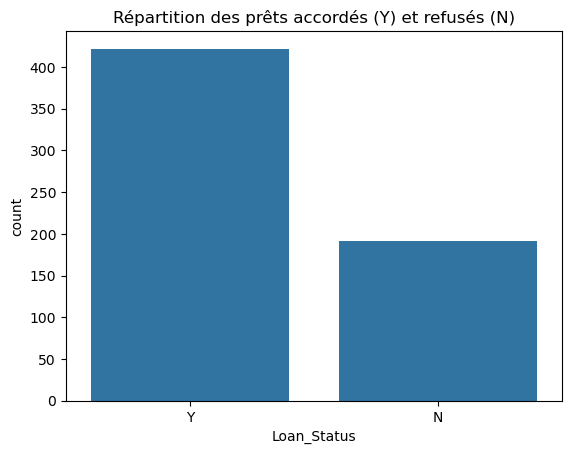

In [109]:
sns.countplot(x='Loan_Status', data=df_loan)
plt.title('Répartition des prêts accordés (Y) et refusés (N)')
plt.show()

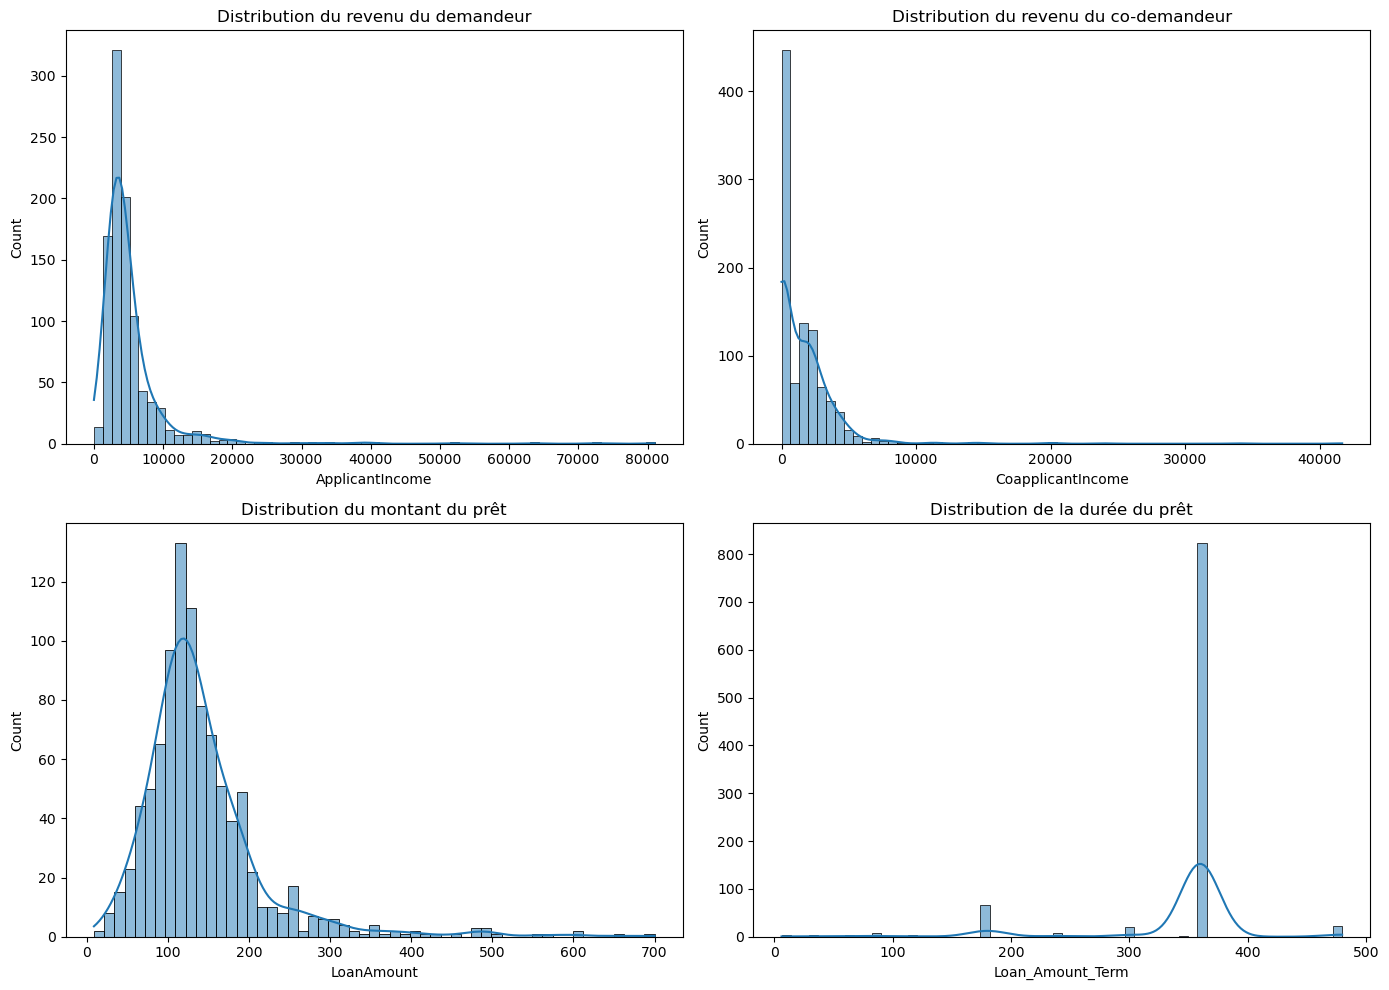

In [146]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_loan['ApplicantIncome'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution du revenu du demandeur')

sns.histplot(df_loan['CoapplicantIncome'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution du revenu du co-demandeur')

sns.histplot(df_loan['LoanAmount'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution du montant du prêt')

sns.histplot(df_loan['Loan_Amount_Term'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution de la durée du prêt')

plt.tight_layout()
plt.show()

In [150]:
df_loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Term_Count
count,981.000000,981.000000,954.000000,961.000000,902.000000,961.000000
mean,5179.795107,1601.916330,142.511530,342.201873,0.835920,710.475546
std,5695.104533,2718.772806,77.421743,65.100602,0.370553,275.115801
min,0.000000,0.000000,9.000000,6.000000,0.000000,1.000000
25%,2875.000000,0.000000,100.000000,360.000000,1.000000,823.000000
50%,3800.000000,1110.000000,126.000000,360.000000,1.000000,823.000000
75%,5516.000000,2365.000000,162.000000,360.000000,1.000000,823.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000,823.000000


- On constate une grande proportion des revenues inférieur à 20000
- De même pour les revenus du co-demandeur largement inférieur à 10000
- Le montant du prêt se situe dans un écart entre 0 et 300/400 avec des cas particulier supérieur à 350
- Concernant la durée du prêt : c'est celle avec 360 qui revient le plus

 Des distributions très asymétriques (skewed) à droite, typiques des revenus. Cela confirme qu'il faudra peut-être une transformation logarithmique ou un scaling robuste.

In [152]:
loan_corr = df_loan[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']]
matrice_corr = loan_corr.corr(numeric_only=True)
print(matrice_corr)

                   ApplicantIncome  CoapplicantIncome  LoanAmount  \
ApplicantIncome           1.000000          -0.114247    0.551811   
CoapplicantIncome        -0.114247           1.000000    0.179228   
LoanAmount                0.551811           0.179228    1.000000   
Loan_Amount_Term         -0.023089          -0.043860    0.055636   
Credit_History            0.023378          -0.027253   -0.008235   

                   Loan_Amount_Term  Credit_History  
ApplicantIncome           -0.023089        0.023378  
CoapplicantIncome         -0.043860       -0.027253  
LoanAmount                 0.055636       -0.008235  
Loan_Amount_Term           1.000000       -0.020439  
Credit_History            -0.020439        1.000000  


<Axes: >

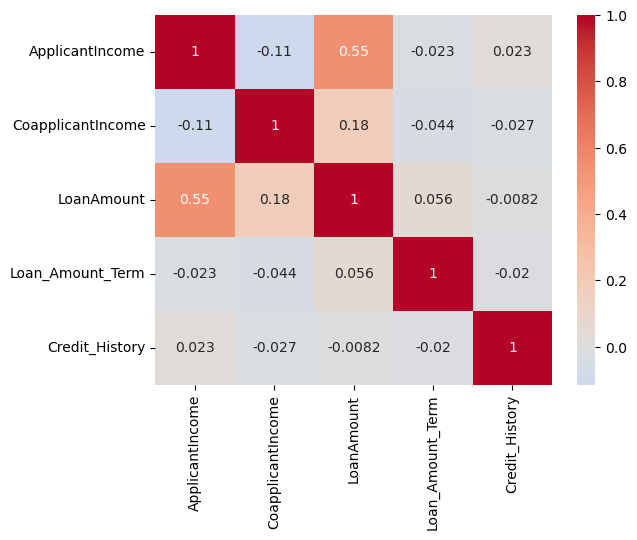

In [153]:
sns.heatmap(matrice_corr,annot=True,cmap = 'coolwarm', center = 0)

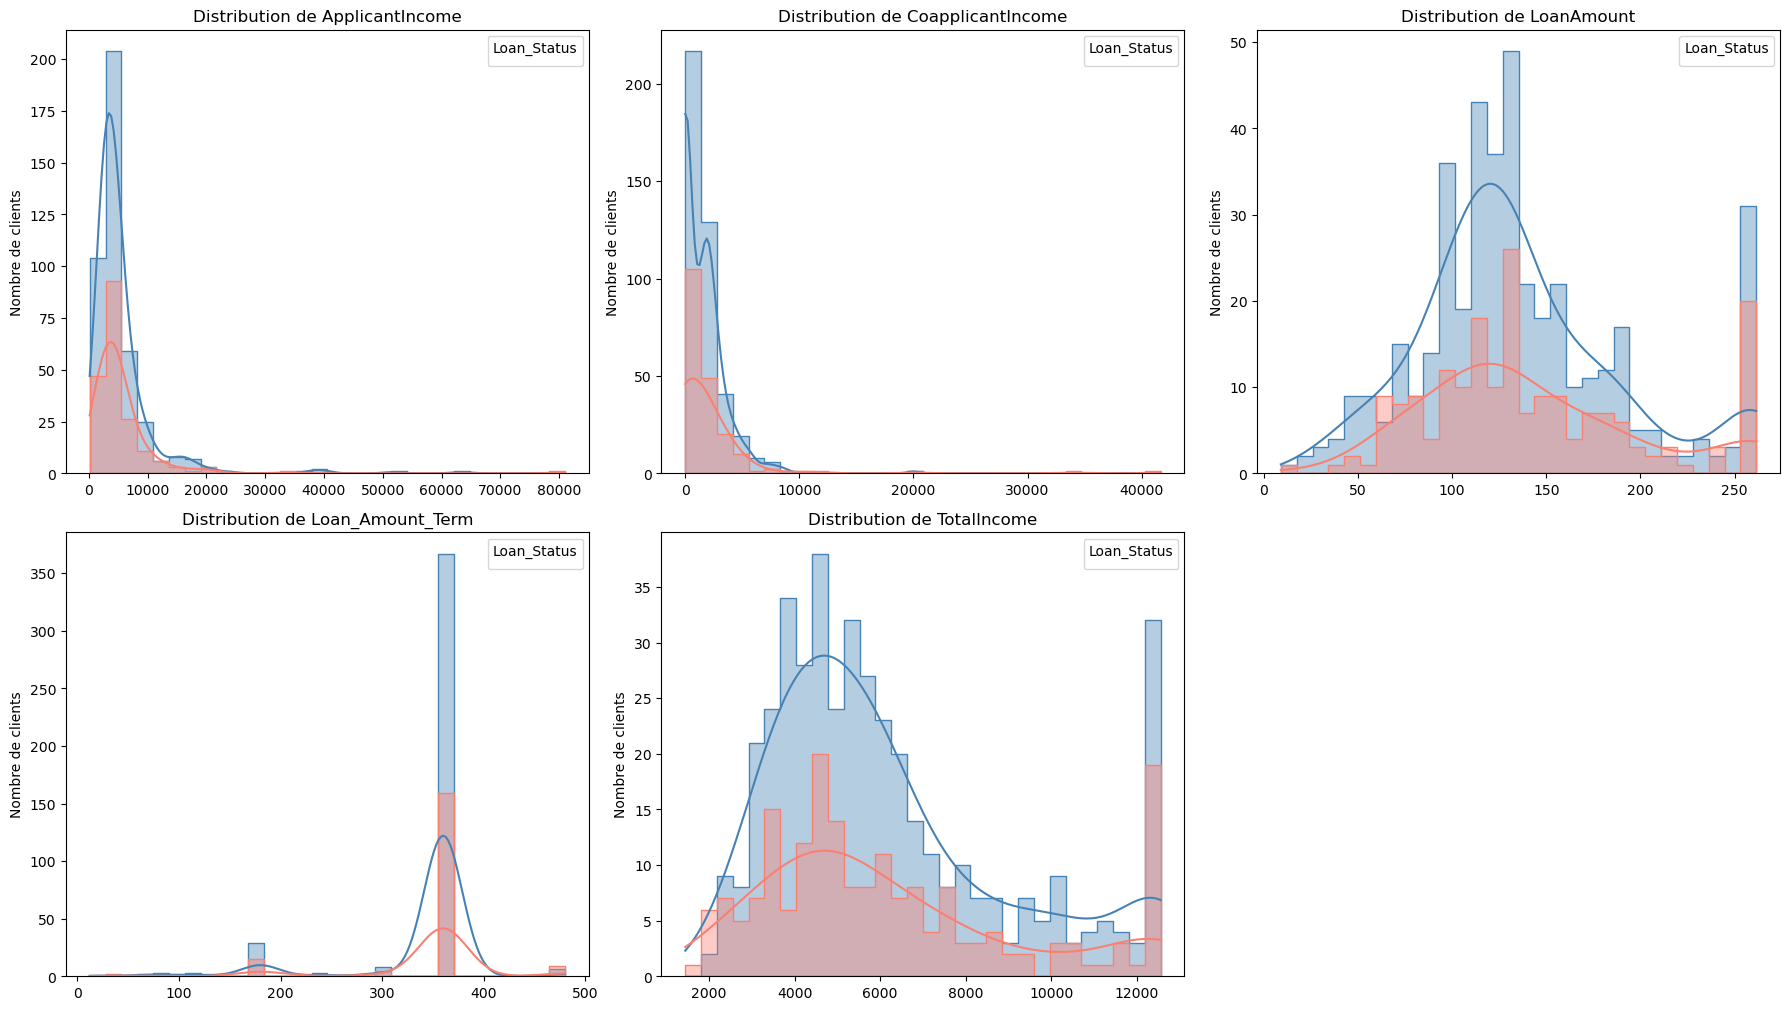

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_vis = df_labeled.copy()

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 
            'Loan_Amount_Term', 'TotalIncome']

# Calcul des stats globales pour la légende
n_total = len(df_vis)
n_defaut = (df_vis['Loan_Status'] == 0).sum()
n_bon = (df_vis['Loan_Status'] == 1).sum()
pct_defaut = n_defaut / n_total * 100
pct_bon = n_bon / n_total * 100

# Légende enrichie (une seule fois, globale)
label_defaut = f'Défaut (0) — n={n_defaut} ({pct_defaut:.1f}%)'
label_bon = f'Bon (1) — n={n_bon} ({pct_bon:.1f}%)'

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df_vis,
        x=col,
        hue='Loan_Status',
        kde=True,
        ax=axes[i],
        palette=['salmon', 'steelblue'],
        element='step',
        stat='count',              # ← Pas de normalisation : comptage brut
        alpha=0.4,
        bins=30
    )
    axes[i].set_title(f'Distribution de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Nombre de clients')
    
    # Légende enrichie par graphique
    handles, labels = axes[i].get_legend_handles_labels()
    axes[i].legend(handles, [label_defaut, label_bon], 
                   title='Loan_Status', loc='upper right', fontsize=9)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

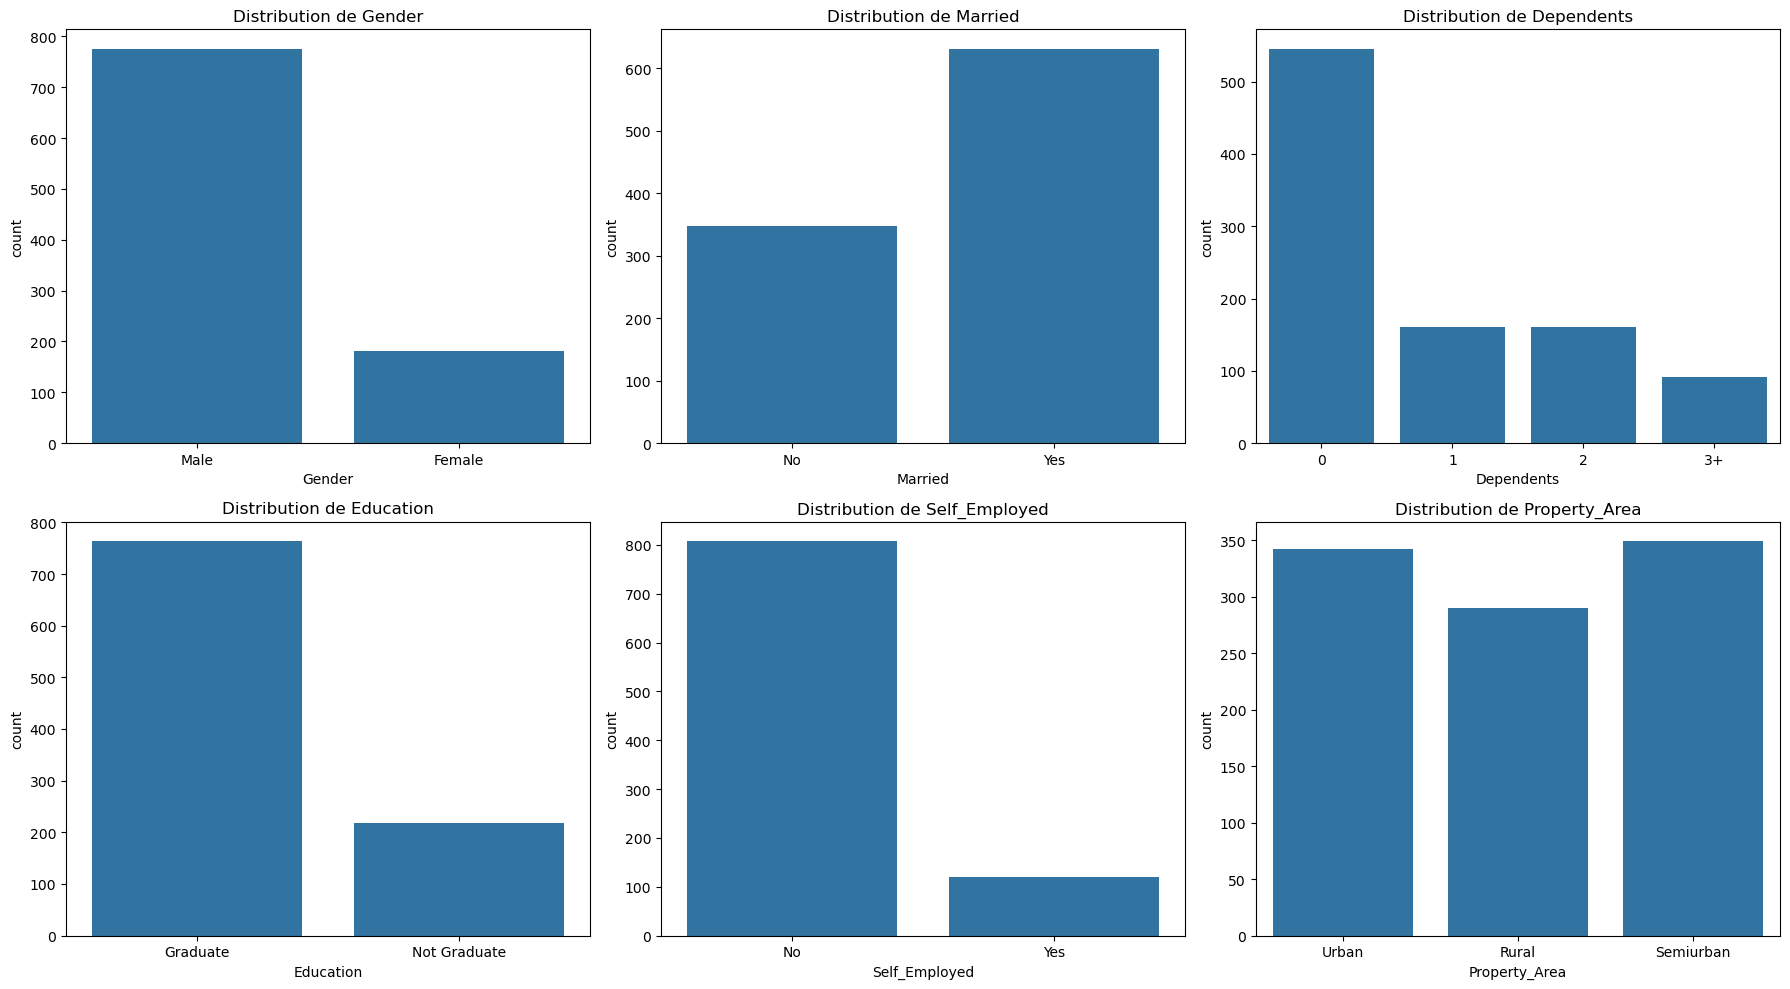

In [111]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df_loan, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'Distribution de {col}')

plt.tight_layout()
plt.show()

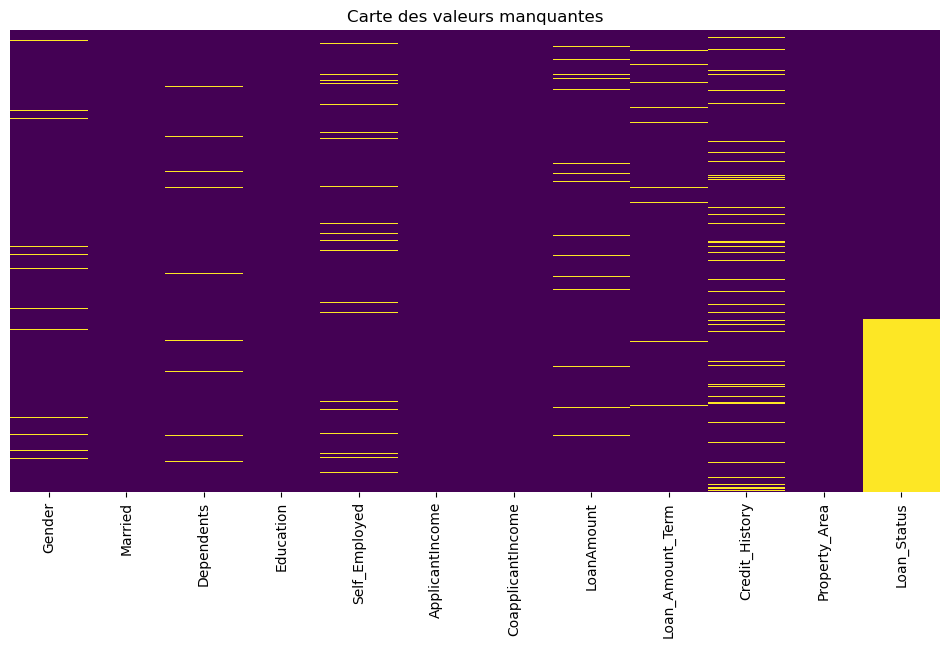

In [112]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_loan.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Carte des valeurs manquantes')
plt.show()

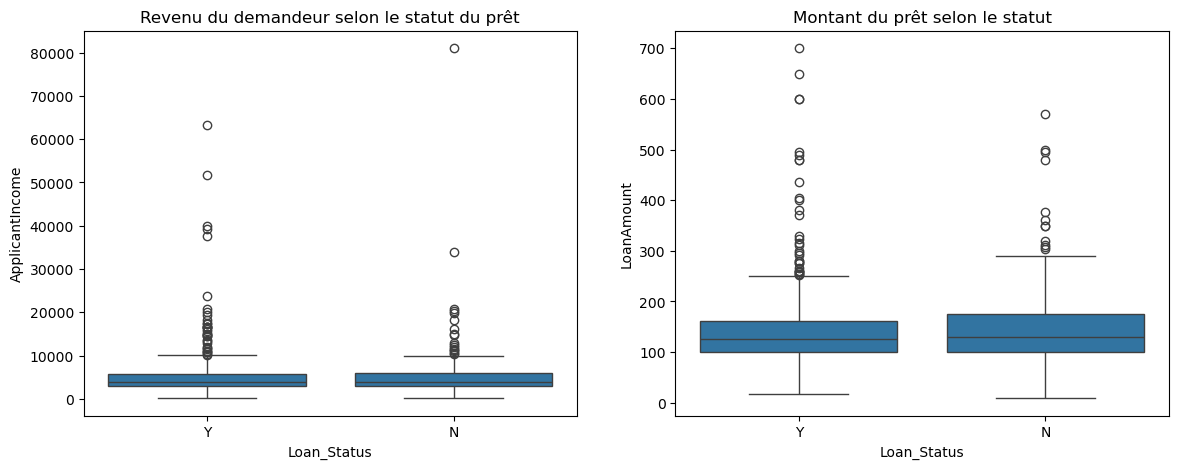

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df_loan, ax=axes[0])
axes[0].set_title('Revenu du demandeur selon le statut du prêt')

sns.boxplot(x='Loan_Status', y='LoanAmount', data=df_loan, ax=axes[1])
axes[1].set_title('Montant du prêt selon le statut')

plt.show()

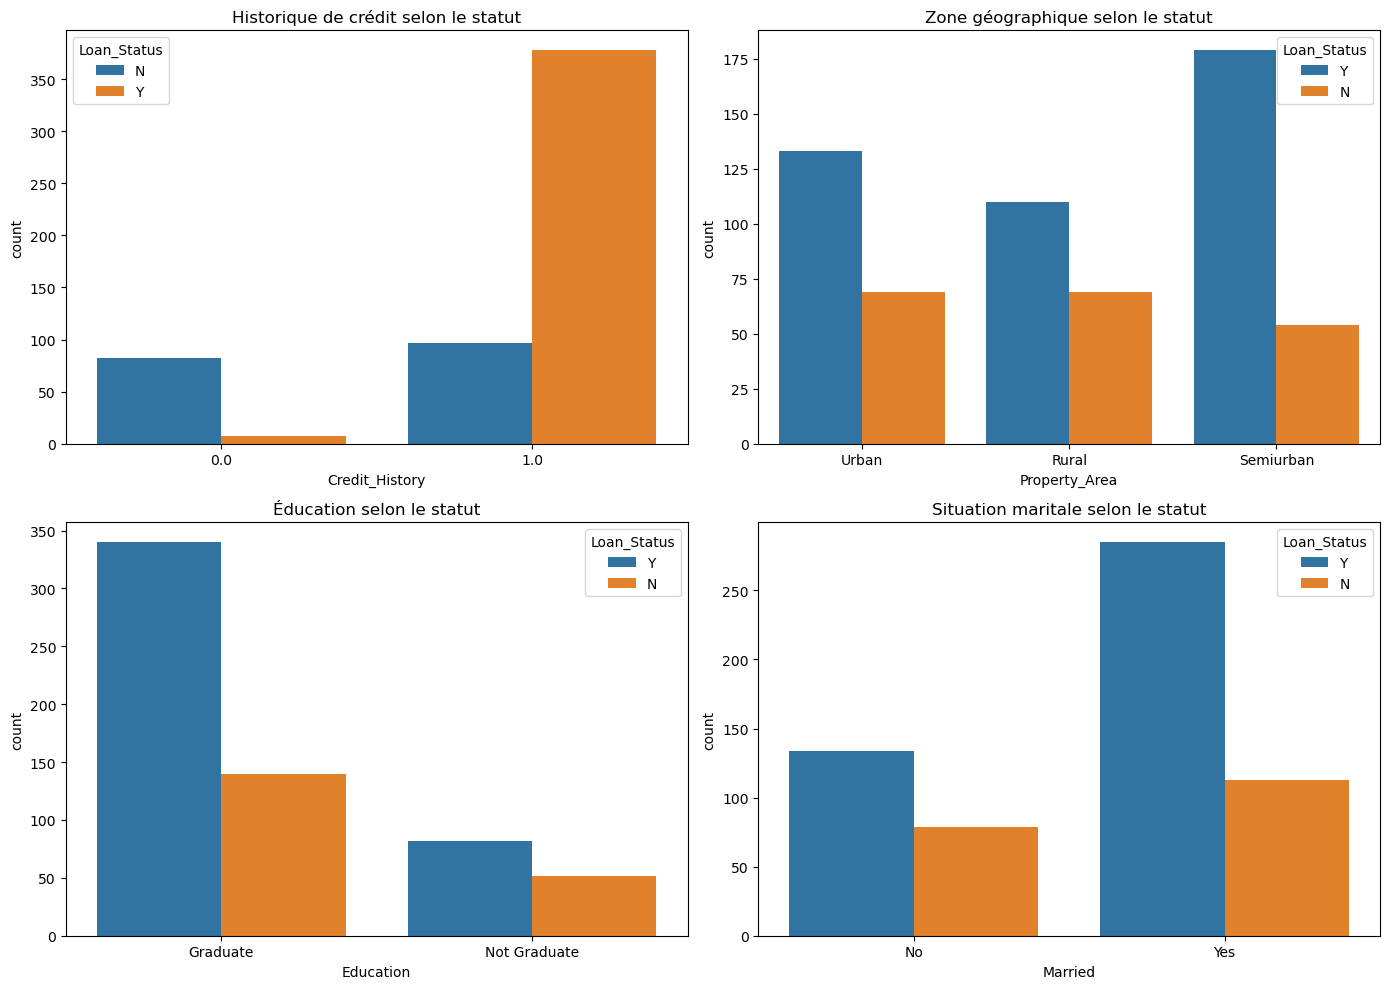

In [114]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='Credit_History', hue='Loan_Status', data=df_loan, ax=axes[0, 0])
axes[0, 0].set_title('Historique de crédit selon le statut')

sns.countplot(x='Property_Area', hue='Loan_Status', data=df_loan, ax=axes[0, 1])
axes[0, 1].set_title('Zone géographique selon le statut')

sns.countplot(x='Education', hue='Loan_Status', data=df_loan, ax=axes[1, 0])
axes[1, 0].set_title('Éducation selon le statut')

sns.countplot(x='Married', hue='Loan_Status', data=df_loan, ax=axes[1, 1])
axes[1, 1].set_title('Situation maritale selon le statut')

plt.tight_layout()
plt.show()

In [115]:
# Calculer le nombre d'occurrences pour chaque valeur
counts = df_loan["Loan_Amount_Term"].value_counts()

# Créer une nouvelle colonne avec le nombre d'occurrences correspondant
df_loan["Term_Count"] = df_loan["Loan_Amount_Term"].map(counts)

# Vérifier le résultat
df_loan.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Term_Count
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,823.0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,823.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,823.0
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,823.0
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,823.0
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y,823.0
6,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y,823.0
7,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N,823.0
8,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y,823.0
9,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N,823.0


In [116]:
# Garder uniquement les prêts refusés (Loan_Status == 'N')
df_refuses = df_loan[df_loan["Loan_Status"] == "N"]

print(f"Nombre de prêts refusés : {len(df_refuses)}")
print(f"Nombre total de prêts étiquetés : {len(df_loan[df_loan['Loan_Status'].notna()])}")
print(f"Taux de refus : {len(df_refuses) / len(df_loan[df_loan['Loan_Status'].notna()]) * 100:.2f}%")

Nombre de prêts refusés : 192
Nombre total de prêts étiquetés : 614
Taux de refus : 31.27%


In [117]:
# Créer une colonne indiquant si Loan_Status est manquant
df_loan['Status_Manquant'] = df_loan['Loan_Status'].isna()

# Vérifier la répartition
print(df_loan['Status_Manquant'].value_counts())
# Attendu : False ~614, True ~367

Status_Manquant
False    614
True     367
Name: count, dtype: int64


Loan_Status                N           Y
Loan_Amount_Term                        
12.0                0.000000  100.000000
36.0              100.000000    0.000000
60.0                0.000000  100.000000
84.0               25.000000   75.000000
120.0               0.000000  100.000000
180.0              34.090909   65.909091
240.0              25.000000   75.000000
300.0              38.461538   61.538462
360.0              29.882812   70.117188
480.0              60.000000   40.000000


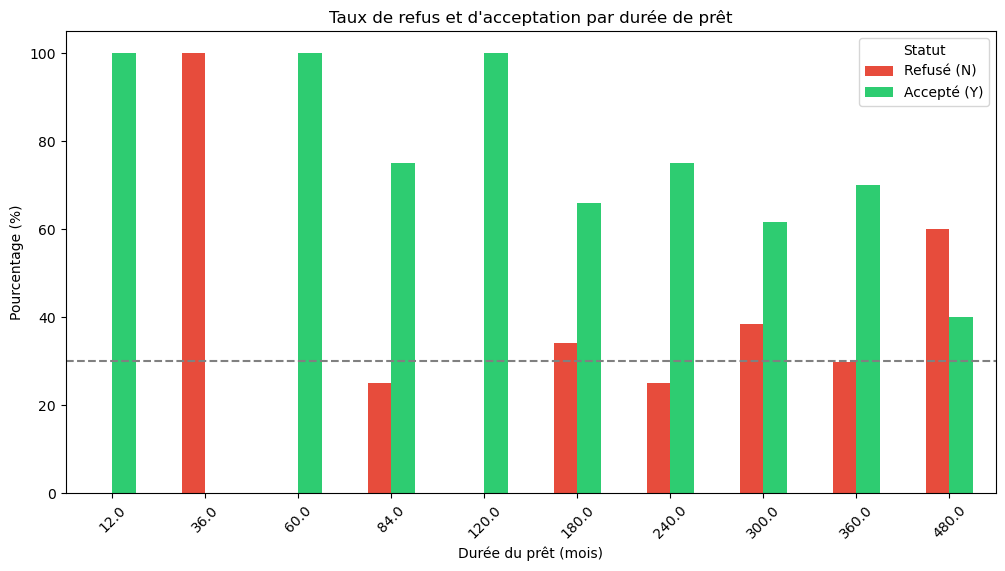

In [118]:
# Tableau croisé en pourcentage
cross_tab = pd.crosstab(df_loan["Loan_Amount_Term"], df_loan["Loan_Status"], normalize="index") * 100

print(cross_tab)

# Visualisation
cross_tab.plot(kind="bar", figsize=(12, 6), color=["#e74c3c", "#2ecc71"])
plt.title("Taux de refus et d'acceptation par durée de prêt")
plt.xlabel("Durée du prêt (mois)")
plt.ylabel("Pourcentage (%)")
plt.legend(title="Statut", labels=["Refusé (N)", "Accepté (Y)"])
plt.xticks(rotation=45)
plt.axhline(y=30, color="gray", linestyle="--", label="Taux moyen de refus")
plt.show()

ValueError: Could not interpret value `Loan_Amount_Term"` for `x`. An entry with this name does not appear in `data`.

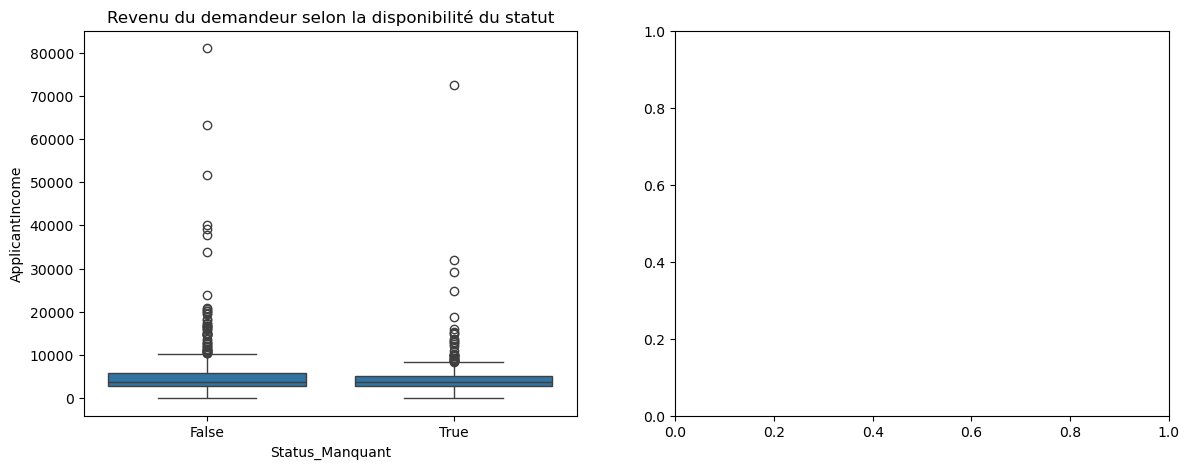

In [119]:
# Comparer les revenus
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Status_Manquant', y='ApplicantIncome', data=df_loan, ax=axes[0])
axes[0].set_title('Revenu du demandeur selon la disponibilité du statut')
sns.boxplot(x='Loan_Amount_Term"', y='ApplicantIncome', data=df_loan, ax=axes[0])
sns.boxplot(x='Status_Manquant', y='LoanAmount', data=df_loan, ax=axes[1])
axes[1].set_title('Montant du prêt selon la disponibilité du statut')

plt.show()

Si les boîtes sont décalées → biais structurel. Par exemple, si les "Statut manquant" ont des revenus plus faibles, cela pourrait signifier que leurs dossiers ont été rejetés sans être enregistrés.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Status_Manquant', data=df_loan, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'{col}')
    axes[i//3, i%3].legend(title='Statut manquant')

plt.tight_layout()
plt.show()

In [120]:
from scipy.stats import chi2_contingency

cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

print("=== Test du Chi-deux : les NaN sont-ils liés aux variables catégorielles ? ===\n")
for col in cat_cols:
    # Table de contingence
    contingency = pd.crosstab(df_loan[col], df_loan['Status_Manquant'])
    
    # Test du Chi-deux
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    # Interprétation
    if p_value < 0.05:
        conclusion = "⚠️ BIAIS STRUCTUREL (rejet de H0)"
    else:
        conclusion = "✅ Aléatoire (on ne rejette pas H0)"
    
    print(f"{col:20s} | Chi2 = {chi2:7.3f} | p-value = {p_value:.4f} | {conclusion}")

=== Test du Chi-deux : les NaN sont-ils liés aux variables catégorielles ? ===

Gender               | Chi2 =   0.094 | p-value = 0.7595 | ✅ Aléatoire (on ne rejette pas H0)
Married              | Chi2 =   0.206 | p-value = 0.6501 | ✅ Aléatoire (on ne rejette pas H0)
Dependents           | Chi2 =   1.895 | p-value = 0.5946 | ✅ Aléatoire (on ne rejette pas H0)
Education            | Chi2 =   0.095 | p-value = 0.7576 | ✅ Aléatoire (on ne rejette pas H0)
Self_Employed        | Chi2 =   1.858 | p-value = 0.1729 | ✅ Aléatoire (on ne rejette pas H0)
Property_Area        | Chi2 =   4.503 | p-value = 0.1052 | ✅ Aléatoire (on ne rejette pas H0)


In [121]:
from scipy.stats import ttest_ind, mannwhitneyu

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

print("=== Test t-test : les NaN sont-ils liés aux variables numériques ? ===\n")
for col in num_cols:
    groupe_connu = df_loan[~df_loan['Status_Manquant']][col].dropna()
    groupe_manquant = df_loan[df_loan['Status_Manquant']][col].dropna()
    
    # Test t-test (ou Mann-Whitney si distributions non-normales)
    t_stat, p_value = ttest_ind(groupe_connu, groupe_manquant, equal_var=False)
    
    # Moyennes
    moy_connu = groupe_connu.mean()
    moy_manquant = groupe_manquant.mean()
    
    if p_value < 0.05:
        conclusion = "⚠️ BIAIS STRUCTUREL"
    else:
        conclusion = "✅ Aléatoire"
    
    print(f"{col:20s} | Moy. connu = {moy_connu:10.2f} | Moy. manquant = {moy_manquant:10.2f} | p = {p_value:.4f} | {conclusion}")

=== Test t-test : les NaN sont-ils liés aux variables numériques ? ===

ApplicantIncome      | Moy. connu =    5403.46 | Moy. manquant =    4805.60 | p = 0.0931 | ✅ Aléatoire
CoapplicantIncome    | Moy. connu =    1621.25 | Moy. manquant =    1569.58 | p = 0.7608 | ✅ Aléatoire
LoanAmount           | Moy. connu =     146.41 | Moy. manquant =     136.13 | p = 0.0315 | ⚠️ BIAIS STRUCTUREL
Loan_Amount_Term     | Moy. connu =     342.00 | Moy. manquant =     342.54 | p = 0.9015 | ✅ Aléatoire


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_21436\40816576.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status_Manquant', y='LoanAmount', data=df_loan,
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_21436\40816576.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Statut connu', 'Statut manquant'])


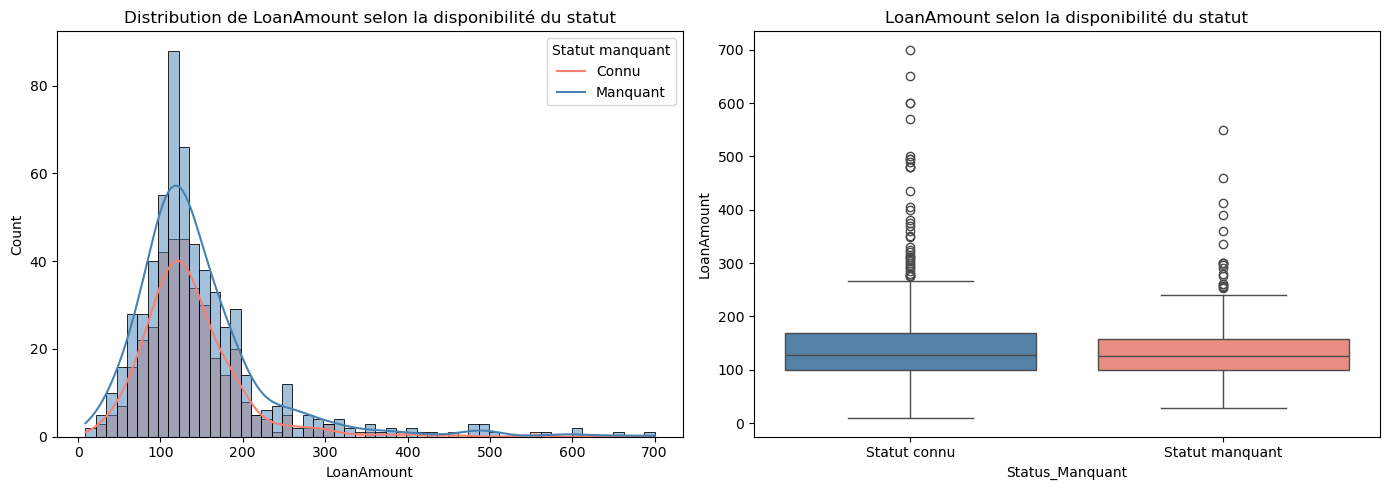

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de LoanAmount selon Status_Manquant
sns.histplot(data=df_loan, x='LoanAmount', hue='Status_Manquant', 
             kde=True, ax=axes[0], palette=['steelblue', 'salmon'])
axes[0].set_title('Distribution de LoanAmount selon la disponibilité du statut')
axes[0].legend(title='Statut manquant', labels=['Connu', 'Manquant'])

# Boxplot
sns.boxplot(x='Status_Manquant', y='LoanAmount', data=df_loan, 
            ax=axes[1], palette=['steelblue', 'salmon'])
axes[1].set_title('LoanAmount selon la disponibilité du statut')
axes[1].set_xticklabels(['Statut connu', 'Statut manquant'])

plt.tight_layout()
plt.show()

In [132]:
# Encoder la cible AVANT le split
df_labeled['Loan_Status'] = df_labeled['Loan_Status'].map({'Y': 1, 'N': 0})

# Vérification
print("Valeurs uniques de Loan_Status :", df_labeled['Loan_Status'].unique())
# Attendu : [1, 0] ou [0, 1]

Valeurs uniques de Loan_Status : [nan]
